In [ ]:
Import & Load Data

In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\RAJU\Desktop\kasa sindhu\traffic.csv")

df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [ ]:
Understand Data

In [2]:
df.info()
df.shape
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   event    226278 non-null  object
 1   date     226278 non-null  object
 2   country  226267 non-null  object
 3   city     226267 non-null  object
 4   artist   226241 non-null  object
 5   album    226273 non-null  object
 6   track    226273 non-null  object
 7   isrc     219157 non-null  object
 8   linkid   226278 non-null  object
dtypes: object(9)
memory usage: 15.5+ MB


Index(['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc',
       'linkid'],
      dtype='object')

In [ ]:
Clean Data

In [3]:
# clean column names
df.columns = df.columns.str.strip().str.lower()

# convert date
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# remove missing important rows
df = df.dropna(subset=['date', 'linkid', 'event'])

# remove duplicates
df = df.drop_duplicates()

# standardize text
df['event'] = df['event'].str.lower().str.strip()
df['country'] = df['country'].str.upper().str.strip()
df['city'] = df['city'].str.title().str.strip()

df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,SAUDI ARABIA,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,INDIA,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,FRANCE,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,MALDIVES,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
5,click,2021-08-21,UNITED STATES,Los Angeles,KenTheMan,I'm Perfect,I'm Perfect,US39N2102090,190c7170-4044-4c97-9709-926917155b02


In [ ]:
Create Sessions

In [4]:
df = df.sort_values(['linkid', 'date'])

df['time_diff'] = df.groupby('linkid')['date'].diff()

df['new_session'] = (df['time_diff'] > pd.Timedelta(minutes=30)) | df['time_diff'].isna()

df['session_id'] = df.groupby('linkid')['new_session'].cumsum()

In [ ]:
Compute Metrics

In [5]:
# users
users = df['linkid'].nunique()

# sessions
sessions = df.groupby(['linkid', 'session_id']).ngroups

# bounce rate
session_counts = df.groupby(['linkid', 'session_id']).size()
bounce_rate = (session_counts == 1).mean()

# avg session duration
session_time = df.groupby(['linkid', 'session_id'])['date'].agg(['min','max'])
session_time['duration'] = session_time['max'] - session_time['min']
avg_duration = session_time['duration'].mean()

print("Users:", users)
print("Sessions:", sessions)
print("Bounce Rate:", bounce_rate)
print("Avg Session Duration:", avg_duration)

Users: 3839
Sessions: 6563
Bounce Rate: 0.2855401493219564
Avg Session Duration: 0 days 00:00:00


In [ ]:
Visualize Funnel

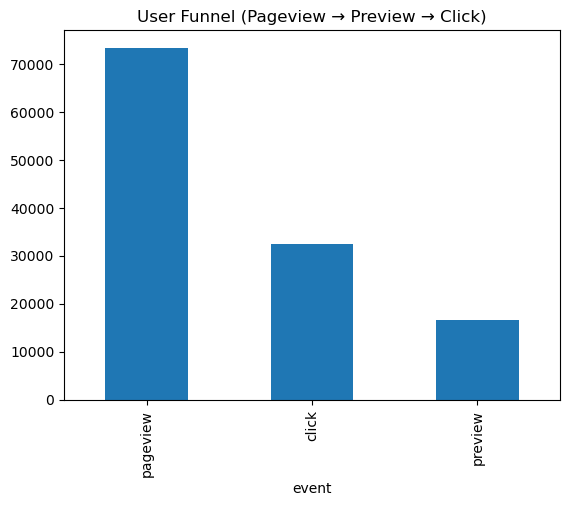

In [6]:
import matplotlib.pyplot as plt

df['event'].value_counts().plot(kind='bar')
plt.title("User Funnel (Pageview → Preview → Click)")
plt.show()

In [ ]:
User Flow (Event Transitions)

In [7]:
df['next_event'] = df.groupby('linkid')['event'].shift(-1)

flow = df.groupby(['event', 'next_event']).size().reset_index(name='count')

flow.sort_values('count', ascending=False).head(10)

,event,next_event,count
4,pageview,pageview,67163
0,click,click,27966
8,preview,preview,14400
1,click,pageview,2495
3,pageview,click,2147
2,click,preview,2036
7,preview,pageview,2009
6,preview,click,299
5,pageview,preview,213


In [ ]:
Top Content

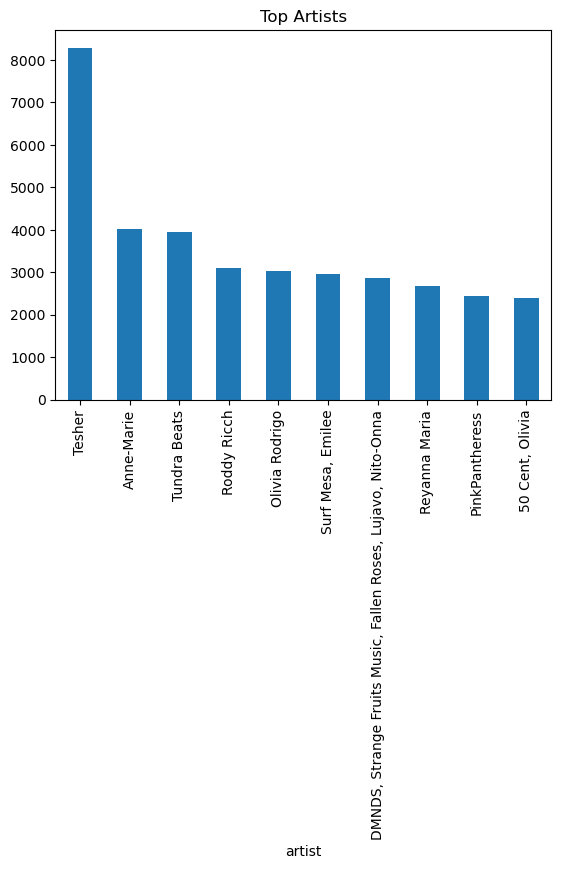

In [8]:
df['artist'].value_counts().head(10).plot(kind='bar')
plt.title("Top Artists")
plt.show()

Insights
- Majority of users only view pages but do not click
- Significant drop from pageview to click
- Some artists generate higher engagement
- Many sessions contain only one event (high bounce)

Recommendations
1. Improve conversion from pageview to click using better CTAs
2. Promote high-performing artists
3. Enhance preview experience
4. Target high-engagement countries
5. Reduce bounce by improving landing experience